# 🚀 Advanced RAG Build with Semantic Chunking | 🏗️ XTALLET


In [1]:
# -------------------------------
# STEP 1: Baseline LangGraph RAG Application using NAIVE RETRIEVAL
# 🔐 LangChain Setup: Enable Tracing & Set API Key  | 🏗️ XTALLET
# -------------------------------
import os
from getpass import getpass
# If you already have the environment variable set, you can skip this line
os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ")

In [2]:
# -------------------------------
# STEP 1: Baseline LangGraph RAG Application using NAIVE RETRIEVAL
# 📄 Load PDFs from 'data/'  | 🏗️ XTALLET
# -------------------------------
# We use DirectoryLoader and PyMuPDFLoader to load all PDFs from the 'data' directory.
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import PyMuPDFLoader

path = 'data/'
loader = DirectoryLoader(path, glob='*.pdf', loader_cls=PyMuPDFLoader)
docs = loader.load()
print(f'Number of documents loaded: {len(docs)}')

Number of documents loaded: 269


In [3]:
# -------------------------------
# STEP 1: Baseline LangGraph RAG Application using NAIVE RETRIEVAL
# ✂️ Chunking documents  | 🏗️ XTALLET
# -------------------------------
# We use RecursiveCharacterTextSplitter to split documents into overlapping chunks.
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
split_documents = text_splitter.split_documents(docs)
print(f'Number of chunks generated: {len(split_documents)}')

Number of chunks generated: 1102


In [4]:
# -------------------------------
# STEP 1: Baseline LangGraph RAG Application using NAIVE RETRIEVAL
# 🧬 Vectorization and in-memory Qdrant  | 🏗️ XTALLET
# -------------------------------
# We create embeddings and store the chunks in an in-memory Qdrant vector store.
from langchain_openai import OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams

embeddings = OpenAIEmbeddings(model='text-embedding-3-small')
client = QdrantClient(':memory:')
client.create_collection(
    collection_name='loan_data',
    vectors_config=VectorParams(size=1536, distance=Distance.COSINE),
)
vector_store = QdrantVectorStore(
    client=client,
    collection_name='loan_data',
    embedding=embeddings,
)
_ = vector_store.add_documents(documents=split_documents)
print('Vector store created and documents indexed.')

Vector store created and documents indexed.


In [5]:
# -------------------------------
# STEP 1: Baseline LangGraph RAG Application using NAIVE RETRIEVAL
# 🔎 Define the Retriever  | 🏗️ XTALLET
# -------------------------------
# We use the Qdrant vector store as a retriever for the RAG pipeline.
retriever = vector_store.as_retriever(search_kwargs={"k": 5})

In [6]:
# -------------------------------
# STEP 1: Baseline LangGraph RAG Application using NAIVE RETRIEVAL
# 🧩 Retrieval Node Function  | 🏗️ XTALLET
# -------------------------------
# This function will be used in the LangGraph pipeline to retrieve relevant documents.
def retrieve(state):
    retrieved_docs = retriever.invoke(state["question"])
    return {"context": retrieved_docs}

In [7]:
# -------------------------------
# STEP 1: Baseline LangGraph RAG Application using NAIVE RETRIEVAL
# 💬 RAG Prompt Template  | 🏗️ XTALLET
# -------------------------------
# This prompt instructs the LLM to answer only using the provided context.
from langchain.prompts import ChatPromptTemplate

RAG_PROMPT = """\
You are a helpful assistant who answers questions based on the provided context. You must only use the provided context, and cannot use your own knowledge.

### Question
{question}

### Context
{context}
"""

rag_prompt = ChatPromptTemplate.from_template(RAG_PROMPT)

In [8]:
# -------------------------------
# STEP 1: Baseline LangGraph RAG Application using NAIVE RETRIEVAL
# 🤖 Generation Node Function  | 🏗️ XTALLET
# -------------------------------
# This function generates an answer using the retrieved context and the RAG prompt.
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4.1-nano")

def generate(state):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = rag_prompt.format_messages(question=state["question"], context=docs_content)
    response = llm.invoke(messages)
    return {"response": response.content}

In [9]:
# -------------------------------
# STEP 1: Baseline LangGraph RAG Application using NAIVE RETRIEVAL
# 🔗 Build LangGraph RAG Pipeline  | 🏗️ XTALLET
# -------------------------------
from langgraph.graph import START, StateGraph
from typing_extensions import List, TypedDict
from langchain_core.documents import Document

class State(TypedDict):
    question: str
    context: List[Document]
    response: str

graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

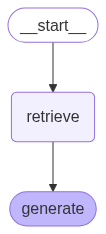

In [12]:
graph

In [10]:
# -------------------------------
# STEP 1: Baseline LangGraph RAG Application using NAIVE RETRIEVAL
# 🧪 Test Baseline RAG Pipeline  | 🏗️ XTALLET
# -------------------------------
# Example: Ask a test question to verify the pipeline works.
response = graph.invoke({"question": "What are the different kinds of loans?"})
print(response["response"])

The provided context mentions different types of loans in relation to student financial assistance, specifically focusing on Direct Loans. The types of loans referenced include:

- **Direct Loan** (including Direct Unsubsidized Loans)
- **Direct Unsubsidized Loan**

While other specific loan types are not explicitly listed in the provided context, it emphasizes the importance of understanding the different repayment plan options and the loan repayment obligations associated with these loans.


In [11]:
# -------------------------------
# STEP 2: Baseline Evaluation using RAGAS METRICS
# 📝 Generate Synthetic Evaluation Dataset  | 🏗️ XTALLET
# -------------------------------
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from ragas.testset import TestsetGenerator

generator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1"))
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())

generator = TestsetGenerator(llm=generator_llm, embedding_model=generator_embeddings)
# You can adjust the number of docs and testset_size as needed
dataset = generator.generate_with_langchain_docs(split_documents[:20], testset_size=10)

Applying SummaryExtractor:   0%|          | 0/19 [00:00<?, ?it/s]

Applying CustomNodeFilter:   0%|          | 0/20 [00:00<?, ?it/s]

Node e6064efb-3b9d-4e15-ba46-69cd2fb0ff92 does not have a summary. Skipping filtering.


Applying [EmbeddingExtractor, ThemesExtractor, NERExtractor]:   0%|          | 0/59 [00:00<?, ?it/s]

Applying OverlapScoreBuilder:   0%|          | 0/1 [00:00<?, ?it/s]

Generating personas:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/2 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/10 [00:00<?, ?it/s]

In [13]:
# -------------------------------
# STEP 2: Baseline Evaluation using RAGAS METRICS
# 🚀 Run Baseline RAG Pipeline on Evaluation Dataset  | 🏗️ XTALLET
# -------------------------------
for test_row in dataset:
    response = graph.invoke({"question": test_row.eval_sample.user_input})
    test_row.eval_sample.response = response["response"]
    test_row.eval_sample.retrieved_contexts = [context.page_content for context in response["context"]]

In [16]:
# -------------------------------
# STEP 2: Baseline Evaluation using RAGAS METRICS
# 🖨️ Display Evaluation Dataset as Pandas DataFrame  | 🏗️ XTALLET
# -------------------------------
import pandas as pd

# If you used the variable 'dataset' from the Ragas testset generator:
df = dataset.to_pandas()
pd.set_option('display.max_colwidth', 200)  # Optional: makes it easier to read long text fields
display(df)  # If in Jupyter, or use print(df) otherwise

,user_input,retrieved_contexts,reference_contexts,response,reference,synthesizer_name
0,"Who is United States Department of Education and what they do with Title IV and schools, I not sure?","[Allegations of suspicious activity by a school or person.\nIndividuals can also submit complaints about the following to the Department:\nApplying for and receiving federal loans, grants, and wor...","[Volume 3\nAcademic Calendars, Cost of Attendance, and\nPackaging\nIntroduction\nThis volume of the Federal Student Aid (FSA) Handbook discusses the academic calendar, payment period, and\ndisburs...","The United States Department of Education (the Department) is responsible for administering federal student aid programs, including those authorized under Title IV of the Higher Education Act of 1...","Throughout this volume of the Handbook, the words ""we,"" ""our,"" and ""us"" refer to the United States Department of Education (the Department). The Department discusses the academic calendar, payment...",single_hop_specifc_query_synthesizer
1,Howw do I use the Help Center for FSA Handbook questons?,"[Your school must provide the following to students selected for verification in a timely manner:\nA clear explanation of their role in the process,\nA list of documents they need to submit, and\n...","[Education Act of 1965, as amended. Title IV refers to the student financial aid programs authorized under Title IV of the\nHEA.\nWe appreciate any comments that you have on this volume as well as...","To use the Help Center for FSA Handbook questions, you should navigate to the FSA Help Center, which is a collection of additional help and resources. Within the Help Center, you can find contact ...",You can reach out through the Contact Customer Support feature in our Partner Connect's Help Center by clicking on FSA Handbook under the Topic section.,single_hop_specifc_query_synthesizer
2,What costs can be included under Tuition and Fees for determining a student's cost of attendance?,"[This allowance is for the tuition and fees normally assessed for a student carrying the same academic workload. It\nincludes, for example, graduation fees, if incurred while the student is still ...","[subscription-based programs.\nChapter 2\nWe have revised the discussion of <Allowable Costs= to clarify that for Pell Grant recipients with an enrollment\nintensity below 50%, the cost of attenda...","Costs that can be included under Tuition and Fees for determining a student's cost of attendance are those normally assessed for a student carrying the same academic workload, such as actual expen...","Under Tuition and Fees, health insurance premiums that are charged to all students may be included as an additional example of a cost in this cost of attendance component.",single_hop_specifc_query_synthesizer
3,"Cud yu pleese explane wut the Children of Fallen Heroes (CFH) provishun wuz and how it relates to the Pell Grant Special Rule, spesifically in the context of the 2025-2026 changes?","[performing the duties of a public safety officer)\nCFH Indicator\n1 3 Eligible for CFH\nEligible 3 Legacy CFH\nCFH Indicator\n2 3 Eligible,\ngrandfathered for\nNote: You must work with any studen...","[that the guidance in this section pertains to credentials that are required for a student to practice or participate in\nthe occupation the program is preparing the student to enter, and have add...","The Children of Fallen Heroes (CFH) provision is a special eligibility category that allows certain students to receive the maximum Pell Grant award. Specifically, if a student indicates on the FA...",The Children of Fallen Heroes (CFH) provision was previously explained in a note that stated the Pell Grant Special Rule replaced the Iraq and Afghanistan Service Grant (IASG) and Children of Fall...,single_hop_specifc_query_synthesizer
4,Whaat is Tittle IV in relashun to akaddemic yeers?,"[Chapter 1\nAcademic Years, Academic Calendars, Payment Periods, and\nDisbursements\nAcademic Year Requi

In [14]:
# -------------------------------
# STEP 2: Baseline Evaluation using RAGAS METRICS
# 📊 Convert to Ragas EvaluationDataset  | 🏗️ XTALLET
# -------------------------------
from ragas import EvaluationDataset

evaluation_dataset = EvaluationDataset.from_pandas(dataset.to_pandas())

In [15]:
# -------------------------------
# STEP 2: Baseline Evaluation using RAGAS METRICS
# 🧮 Evaluate with RAGAS Metrics  | 🏗️ XTALLET
# -------------------------------
from ragas import evaluate
from ragas.llms import LangchainLLMWrapper
from langchain_openai import ChatOpenAI
from ragas.metrics import (
    LLMContextRecall,
    Faithfulness,
    FactualCorrectness,
    ResponseRelevancy,
    ContextEntityRecall,
    NoiseSensitivity
)
from ragas import RunConfig

evaluator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-mini"))
custom_run_config = RunConfig(timeout=360)

result = evaluate(
    dataset=evaluation_dataset,
    metrics=[
        LLMContextRecall(),
        Faithfulness(),
        FactualCorrectness(),
        ResponseRelevancy(),
        ContextEntityRecall(),
        NoiseSensitivity()
    ],
    llm=evaluator_llm,
    run_config=custom_run_config
)
print(result)

Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

{'context_recall': 0.8700, 'faithfulness': 0.8227, 'factual_correctness': 0.4580, 'answer_relevancy': 0.9391, 'context_entity_recall': 0.4254, 'noise_sensitivity_relevant': 0.4517}


In [23]:
# -------------------------------
# STEP 3: Implement a SEMANTIC CHUNKING STRATEGY
# 📦 Install and Download NLTK Data  | 🏗️ XTALLET
# -------------------------------
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /home/xtallet/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/xtallet/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [18]:
# -------------------------------
# STEP 3: Implement a SEMANTIC CHUNKING STRATEGY
# 🧠 Semantic Chunking Function (Greedy Sentence Grouping)  | 🏗️ XTALLET
# -------------------------------
import numpy as np
from langchain_openai import OpenAIEmbeddings
from nltk.tokenize import sent_tokenize
from tqdm import tqdm

def semantic_chunk_document(
    text,
    embeddings_model,
    similarity_threshold=0.80,
    max_chunk_size=1000
):
    """
    Greedily group semantically similar sentences into chunks.
    - similarity_threshold: minimum cosine similarity to add a sentence to the current chunk
    - max_chunk_size: maximum number of characters per chunk
    """
    sentences = sent_tokenize(text)
    if not sentences:
        return []
    sentence_embeddings = embeddings_model.embed_documents(sentences)
    chunks = []
    current_chunk = sentences[0]
    current_embedding = sentence_embeddings[0]
    for i in range(1, len(sentences)):
        next_sentence = sentences[i]
        next_embedding = sentence_embeddings[i]
        # Compute cosine similarity
        sim = np.dot(current_embedding, next_embedding) / (
            np.linalg.norm(current_embedding) * np.linalg.norm(next_embedding)
        )
        # Check if adding the sentence keeps the chunk semantically coherent and under max size
        if (
            sim >= similarity_threshold
            and len(current_chunk) + len(next_sentence) + 1 <= max_chunk_size
        ):
            current_chunk += " " + next_sentence
            # Update the embedding as the mean of the chunk so far
            current_embedding = (
                np.array(embeddings_model.embed_documents([current_chunk]))[0]
            )
        else:
            chunks.append(current_chunk)
            current_chunk = next_sentence
            current_embedding = next_embedding
    chunks.append(current_chunk)
    return chunks

In [24]:
# -------------------------------
# STEP 3: Implement a SEMANTIC CHUNKING STRATEGY
# 🗂️ Apply Semantic Chunking to All Documents  | 🏗️ XTALLET
# -------------------------------
semantic_chunks = []
embeddings_model = OpenAIEmbeddings(model='text-embedding-3-small')

for doc in tqdm(docs, desc="Semantic chunking"):
    text = doc.page_content
    doc_chunks = semantic_chunk_document(
        text,
        embeddings_model=embeddings_model,
        similarity_threshold=0.80,  # You can adjust this threshold
        max_chunk_size=1000         # You can adjust this size
    )
    # Store as LangChain Document objects for compatibility
    for chunk in doc_chunks:
        semantic_chunks.append(type(doc)(page_content=chunk, metadata=doc.metadata))

print(f"Number of semantic chunks generated: {len(semantic_chunks)}")

Semantic chunking: 100%|██████████| 269/269 [02:50<00:00,  1.57it/s]

Number of semantic chunks generated: 4533


In [25]:
# -------------------------------
# STEP 4: LangGraph RAG with SEMANTIC CHUNKING
# 🧬 Vectorize Semantic Chunks and Store in Qdrant  | 🏗️ XTALLET
# -------------------------------
from langchain_openai import OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams

semantic_embeddings = OpenAIEmbeddings(model='text-embedding-3-small')
semantic_client = QdrantClient(':memory:')
semantic_client.create_collection(
    collection_name='semantic_chunks',
    vectors_config=VectorParams(size=1536, distance=Distance.COSINE),
)
semantic_vector_store = QdrantVectorStore(
    client=semantic_client,
    collection_name='semantic_chunks',
    embedding=semantic_embeddings,
)
_ = semantic_vector_store.add_documents(documents=semantic_chunks)
print('Semantic vector store created and semantic chunks indexed.')

Semantic vector store created and semantic chunks indexed.


In [26]:
# -------------------------------
# STEP 4: LangGraph RAG with SEMANTIC CHUNKING
# 🔎 Define the Retriever for Semantic Chunks  | 🏗️ XTALLET
# -------------------------------
semantic_retriever = semantic_vector_store.as_retriever(search_kwargs={"k": 5})

In [28]:
# -------------------------------
# STEP 4: LangGraph RAG with SEMANTIC CHUNKING
# 🧩 Retrieval Node Function (Semantic)  | 🏗️ XTALLET
# -------------------------------
def semantic_retrieve(state):
    retrieved_docs = semantic_retriever.invoke(state["question"])
    return {"context": retrieved_docs}

In [29]:
# -------------------------------
# STEP 4: LangGraph RAG with SEMANTIC CHUNKING
# 🔗 Build LangGraph RAG Pipeline (Semantic Chunks)  | 🏗️ XTALLET
# -------------------------------
from langgraph.graph import START, StateGraph
from typing_extensions import List, TypedDict
from langchain_core.documents import Document

class SemanticState(TypedDict):
    question: str
    context: List[Document]
    response: str

semantic_graph_builder = StateGraph(SemanticState).add_sequence([semantic_retrieve, generate])
semantic_graph_builder.add_edge(START, "semantic_retrieve")
semantic_graph = semantic_graph_builder.compile()

In [30]:
# -------------------------------
# STEP 4: LangGraph RAG with SEMANTIC CHUNKING
# 🧪 Test Semantic Chunking RAG Pipeline  | 🏗️ XTALLET
# -------------------------------
response = semantic_graph.invoke({"question": "What are the different kinds of loans?"})
print(response["response"])

The different kinds of loans mentioned are:

1. Subsidized Federal Stafford Loans
2. Unsubsidized Federal Stafford Loans
3. Federal SLS Loans
4. Federal PLUS Loans
5. Direct Unsubsidized Loans
6. TEACH Grants (though technically a grant, not a loan)
7. State loans
8. Private education loans
9. Other non-need-based loans


In [31]:
# -------------------------------
# STEP 5: Compare and contrast results
# 🧮 Evaluate Semantic Chunking Pipeline with RAGAS  | 🏗️ XTALLET
# -------------------------------
from copy import deepcopy

# Deepcopy the original dataset to avoid overwriting
semantic_dataset = deepcopy(dataset)

for test_row in semantic_dataset:
    response = semantic_graph.invoke({"question": test_row.eval_sample.user_input})
    test_row.eval_sample.response = response["response"]
    test_row.eval_sample.retrieved_contexts = [context.page_content for context in response["context"]]

from ragas import EvaluationDataset

semantic_evaluation_dataset = EvaluationDataset.from_pandas(semantic_dataset.to_pandas())

In [32]:
# -------------------------------
# STEP 5: Compare and contrast results
# 📊 Evaluate with RAGAS Metrics (Semantic Chunking)  | 🏗️ XTALLET
# -------------------------------
result_semantic = evaluate(
    dataset=semantic_evaluation_dataset,
    metrics=[
        LLMContextRecall(),
        Faithfulness(),
        FactualCorrectness(),
        ResponseRelevancy(),
        ContextEntityRecall(),
        NoiseSensitivity()
    ],
    llm=evaluator_llm,
    run_config=custom_run_config
)
print("Semantic Chunking RAGAS Results:")
print(result_semantic)

Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

Semantic Chunking RAGAS Results:
{'context_recall': 0.5052, 'faithfulness': 0.8252, 'factual_correctness': 0.4810, 'answer_relevancy': 0.9343, 'context_entity_recall': 0.3879, 'noise_sensitivity_relevant': 0.2833}


In [35]:
# -------------------------------
# STEP 5: Compare and contrast results
# 📈 Compare Baseline vs Semantic Chunking Results  | 🏗️ XTALLET
# -------------------------------
import pandas as pd

# Try to convert EvaluationResult to dict using .items() or __dict__ fallback
def result_to_dict(res):
    if hasattr(res, "items"):
        return dict(res.items())
    elif hasattr(res, "__dict__"):
        # Sometimes the results are stored in a .results attribute
        if hasattr(res, "results"):
            return res.results
        return res.__dict__
    else:
        raise ValueError("Cannot convert result to dict")

baseline_dict = result_to_dict(result)
semantic_dict = result_to_dict(result_semantic)

df_compare = pd.DataFrame({
    "Baseline": list(baseline_dict.values()),
    "Semantic Chunking": list(semantic_dict.values())
}, index=list(baseline_dict.keys()))

display(df_compare)
# Or, if not in Jupyter:
# print(df_compare)

,Baseline,Semantic Chunking
scores,"[{'context_recall': 1.0, 'faithfulness': 0.9411764705882353, 'factual_correctness': 0.08, 'answer_relevancy': 0.9181185436128412, 'context_entity_recall': 0.7499999981250001, 'noise_sensitivity_re...","[{'context_recall': 0.5, 'faithfulness': 0.9375, 'factual_correctness': 0.0, 'answer_relevancy': 0.9138382858333723, 'context_entity_recall': 0.49999999875, 'noise_sensitivity_relevant': 0.8888888..."
dataset,"(user_input='Who is United States Department of Education and what they do with Title IV and schools, I not sure?' retrieved_contexts=['Allegations of suspicious activity by a school or person.\nI...","(user_input='Who is United States Department of Education and what they do with Title IV and schools, I not sure?' retrieved_contexts=['<We= indicates the U.S. Department of Education (the Departm..."
binary_columns,[],[]
cost_cb,None,None
traces,"[{'context_recall': {'context_recall_classification_prompt': {'input': QCA(question='Who is United States Department of Education and what they do with Title IV and schools, I not sure?', context=...","[{'context_recall': {'context_recall_classification_prompt': {'input': QCA(question='Who is United States Department of Education and what they do with Title IV and schools, I not sure?', context=..."
ragas_traces,{'92997ac6-c3c3-49b3-be33-7bebeed848c1': run_id='92997ac6-c3c3-49b3-be33-7bebeed848c1' parent_run_id=None name='ragas evaluation' inputs={} metadata={'type': <ChainType.EVALUATION: 'evaluation'>} ...,{'46f597af-c177-48c7-97a2-8b60b6aa8eeb': run_id='46f597af-c177-48c7-97a2-8b60b6aa8eeb' parent_run_id=None name='ragas evaluation' inputs={} metadata={'type': <ChainType.EVALUATION: 'evaluation'>} ...
run_id,None,None
_scores_dict,"{'context_recall': [1.0, 1.0, 1.0, 1.0, 1.0, 0.5, 0.6, 1.0, 1.0, 0.6], 'faithfulness': [0.9411764705882353, 1.0, 0.75, 1.0, 1.0, 1.0, 0.967741935483871, 0.6, 0.35714285714285715, 0.611111111111111...","{'context_recall': [0.5, 1.0, 0.0, 0.5, 1.0, 0.5, 0.4, 0.6666666666666666, 0.2857142857142857, 0.2], 'faithfulness': [0.9375, 1.0, 1.0, 0.9411764705882353, 1.0, 1.0, 0.7, 0.9230769230769231, 0.083..."
_repr_dict,"{'context_recall': 0.8699999999999999, 'faithfulness': 0.8227172374326075, 'factual_correctness': 0.458, 'answer_relevancy': 0.9391338124494023, 'context_entity_recall': 0.42541083033068805, 'nois...","{'context_recall': 0.5052380952380953, 'faithfulness': 0.8251753393665158, 'factual_correctness': 0.481, 'answer_relevancy': 0.9343162643677904, 'context_entity_recall': 0.3878758164084175, 'noise..."


In [43]:
print(df_compare.applymap(type))

                                                        Baseline  \
scores                                            <class 'list'>   
dataset         <class 'ragas.dataset_schema.EvaluationDataset'>   
binary_columns                                    <class 'list'>   
cost_cb                                       <class 'NoneType'>   
traces                                            <class 'list'>   
ragas_traces                                      <class 'dict'>   
run_id                                        <class 'NoneType'>   
_scores_dict                                      <class 'dict'>   
_repr_dict                                        <class 'dict'>   

                                               Semantic Chunking  
scores                                            <class 'list'>  
dataset         <class 'ragas.dataset_schema.EvaluationDataset'>  
binary_columns                                    <class 'list'>  
cost_cb                                       <clas

/tmp/ipykernel_61669/1134127263.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(df_compare.applymap(type))


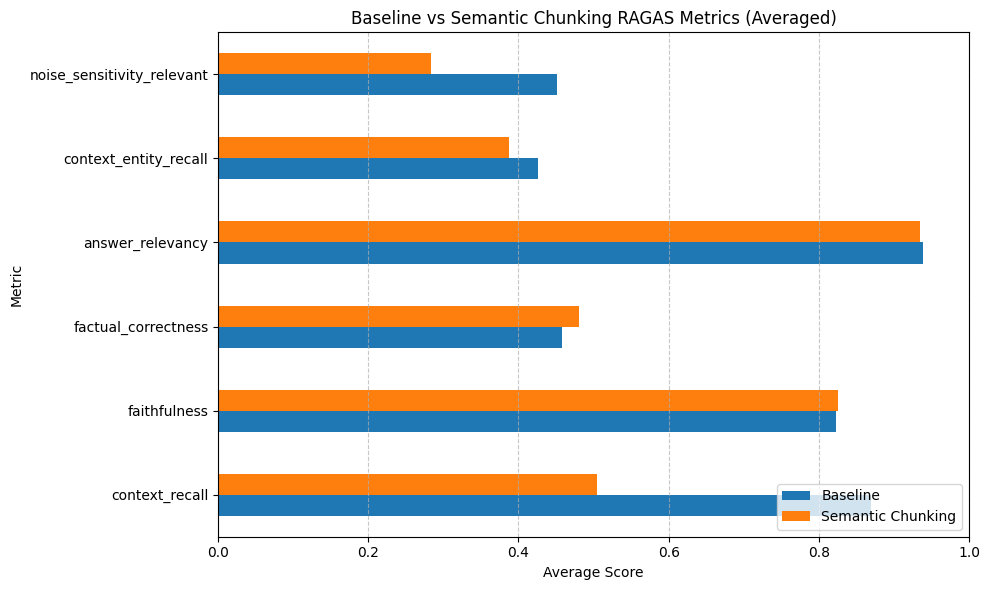

In [49]:
# -------------------------------
# STEP 5: Compare and contrast results
# 📉 Bar Plot Comparison (Averaged Metrics)  | 🏗️ XTALLET
# -------------------------------
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Tus resultados
baseline_scores_dict = result._scores_dict
semantic_scores_dict = result_semantic._scores_dict

# Calcula el promedio de cada métrica
metric_names = list(baseline_scores_dict.keys())
baseline_means = [float(np.mean(baseline_scores_dict[k])) for k in metric_names]
semantic_means = [float(np.mean(semantic_scores_dict[k])) for k in metric_names]

# Crea el DataFrame
df_plot = pd.DataFrame({
    "Baseline": baseline_means,
    "Semantic Chunking": semantic_means
}, index=metric_names)

# Grafica
ax = df_plot.round(4).plot(kind='barh', figsize=(10, 6))
plt.title("Baseline vs Semantic Chunking RAGAS Metrics (Averaged)")
plt.xlabel("Average Score")
plt.ylabel("Metric")
plt.xlim(0, 1)
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [48]:
result_semantic._scores_dict

{'context_recall': [0.5,
  1.0,
  0.0,
  0.5,
  1.0,
  0.5,
  0.4,
  0.6666666666666666,
  0.2857142857142857,
  0.2],
 'faithfulness': [0.9375,
  1.0,
  1.0,
  0.9411764705882353,
  1.0,
  1.0,
  0.7,
  0.9230769230769231,
  0.08333333333333333,
  0.6666666666666666],
 'factual_correctness': [np.float64(0.0),
  np.float64(0.8),
  np.float64(0.0),
  np.float64(0.45),
  np.float64(0.6),
  np.float64(0.38),
  np.float64(0.5),
  np.float64(0.59),
  np.float64(0.71),
  np.float64(0.78)],
 'answer_relevancy': [np.float64(0.9138382858333723),
  np.float64(0.9843978232037842),
  np.float64(1.0000000000000013),
  np.float64(0.8917453911775417),
  np.float64(0.8872140904116841),
  np.float64(0.9003442311655139),
  np.float64(0.9460010883701325),
  np.float64(0.9309839406775536),
  np.float64(0.8886377928383199),
  np.float64(1.0)],
 'context_entity_recall': [0.49999999875,
  0.3999999992,
  0.0,
  0.8333333319444445,
  0.6666666655555555,
  0.1111111109876543,
  0.3333333331746032,
  0.66666666